## Vision Transformer (ViT) Basic Code: Pretrained model
```
What Are We Doing?
Our Goal:
We're using a pretrained Vision Transformer model to classify an image. This is inference only (not training). We're:
Loading a model already trained on ImageNet (1.2 million images)
Giving it an image
Getting predictions of what's in the image

Training: Model learns from data
Inference: Model uses what it learned to predict on new data (we are doing inference only)

Understanding the Model First
What is ViT-Base-Patch16-224?
This is a specific Vision Transformer model with these specifications:
```
```
Parameter	              Value	                     Meaning
Name	                      vit-base-patch16-224	     Base size model
Patch Size	              16×16 pixels	             Each patch is 16×16
Input Size	              224×224 pixels	             Image resized to 224×224
Number of Patches	      196	                     (224/16)² = 196 patches (area/area)
Embedding Dimension	      768	                     Each patch → 768-dim vector
Number of Heads	              12	                     Multi-head attention
Transformer Layers	      12	                     Encoder layers
Total Parameters	      86 Million	             Learnable weights
```
```
PART 2: Detailed Architecture Breakdown
How ViT Processes an Image:
Step 1: Input Image (224×224×3)
┌─────────────────────────────────────────────────────┐
│  RGB Image - 224 pixels wide × 224 pixels tall      │
│  3 color channels (Red, Green, Blue)                │
└─────────────────────────────────────────────────────┘
                        ↓
Step 2: Split into Patches (16×16 each)
┌────┬────┬────┬────┬────┬────┬────┬────┬────┬────┬────┬────┬────┬────┐
│P1  │P2  │P3  │P4  │P5  │P6  │P7  │P8  │P9  │P10 │P11 │P12 │P13 │P14 │
├────┼────┼────┼────┼────┼────┼────┼────┼────┼────┼────┼────┼────┼────┤
│... │... │... │... │... │... │... │... │... │... │... │... │... │... │
└────┴────┴────┴────┴────┴────┴────┴────┴────┴────┴────┴────┴────┴────┘
196 patches total (14×14 grid) [14 patches per row, 14 rows total]
Each patch = 16×16×3 = 768 numbers
                        ↓
Step 3: Patch Embedding (Linear Projection)
Each patch (768 numbers) → Linear Layer → Vector (768 dimensions)

[Patch1] → [e₁, e₂, e₃, ..., e₇₆₈]
[Patch2] → [e₁, e₂, e₃, ..., e₇₆₈]
...
[Patch196] → [e₁, e₂, e₃, ..., e₇₆₈]
                        ↓
Step 4: Add Classification Token (CLS)
[CLS] + [Patch1] + [Patch2] + ... + [Patch196]
  ↑
Special learnable token that will represent the whole image
                        ↓
Step 5: Add Positional Embeddings
Each token gets a unique position identifier
[CLS+pos0], [Patch1+pos1], [Patch2+pos2], ..., [Patch196+pos196]
                        ↓
Step 6: Transformer Encoder (12 Layers) [Encoder Only, this part is repeated 12 times]
Each layer does:
┌─────────────────────────────────────────────────────┐
│  LayerNorm → Multi-Head Self-Attention (12 heads)   │
│  Add Residual Connection                            │
│  LayerNorm → Feed Forward Network (MLP)             │
│  Add Residual Connection                            │
└─────────────────────────────────────────────────────┘
                        ↓
Step 7: Classification Head
Take CLS token output (768-dim)
  ↓
MLP Layer: 768 → 1000 (ImageNet classes, total 1000 classes)
  ↓
Output: 1000 class probabilities
```

### SECTION 1: IMPORTS

In [ ]:
import torch                                                            
from transformers import ViTForImageClassification, AutoImageProcessor   
from PIL import Image
import matplotlib.pyplot as plt

```
Import	                         Purpose	           What It Provides
torch	                         Core PyTorch	           Tensor operations, GPU support
ViTForImageClassification	 HuggingFace ViT model	   Pretrained ViT with classification head
AutoImageProcessor	         Image preprocessing	   Resize, normalize, convert to patches
PIL.Image	                 Image loading	           Open and manipulate images
matplotlib.pyplot	         Visualization	           Display images and predictions

### SECTION 2: LOAD PRETRAINED ViT

In [ ]:
# 1
model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224'
)
# 2 
processor = AutoImageProcessor.from_pretrained(           
    'google/vit-base-patch16-224'
)
# 3
model.eval()

config.json: 0.00B [00:00, ?B/s]

d:\Python\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\OLIVE\.cache\huggingface\hub\models--google--vit-base-patch16-224. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

```
What happens here:
# 1
Downloads model weights (≈330 MB) from HuggingFace
Creates the complete ViT architecture:
Patch embedding layer (projects 16×16 patches to 768-dim)
Positional embeddings (197 positions: 1 CLS + 196 patches)
12 Transformer encoder layers
Classification head (768 → 1000 ImageNet classes)

# 2
What the processor does:
Resizes image to 224×224
Converts to tensor
Normalizes with ImageNet stats (mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
Prepares for model input

# 3
Why this is important:
Sets model to evaluation mode
Disables dropout (which is only used during training)
Disables batch normalization updates 
Ensures consistent predictions


### SECTION 3: Load Image

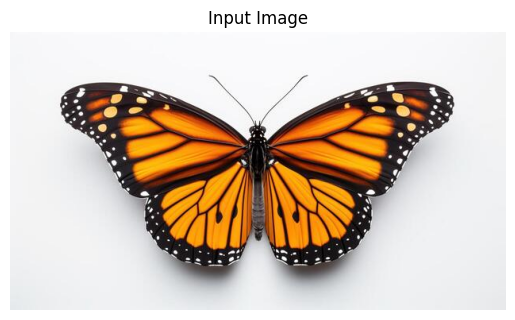

In [19]:
image = Image.open("image.png").convert("RGB")

plt.imshow(image)
plt.title("Input Image")
plt.axis('off')
plt.show()

```
What happens:
Opens image file from disk
.convert("RGB") ensures 3 color channels
If image is grayscale or RGBA, converts to RGB

### SECTION 4: Preprocess + Predict

In [20]:
inputs = processor(images=image, return_tensors="pt")       # pt stands for PyTorch tensors

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
predicted_class = logits.argmax(-1)       

print("Predicted class ID:", predicted_class.item())
print("Predicted class label:", model.config.id2label[predicted_class.item()])


Predicted class ID: 323
Predicted class label: monarch, monarch butterfly, milkweed butterfly, Danaus plexippus


```
What happens inside processor:
Resize: Image → 224×224
Convert to Tensor: (224,224,3) → (3,224,224)
Normalize: pixel = (pixel - 0.5) / 0.5 → range [-1, 1]
Add Batch Dimension: (3,224,224) → (1,3,224,224)
Return as PyTorch tensor

torch.no_grad() context manager:
Disables gradient computation
Saves memory (no need to store computation graph) [Its not training, only inference]
Speeds up inference
Essential for evaluation/prediction
model(**inputs) passes the pixel_values to the model

logits = outputs.logits
predicted_class = logits.argmax(-1)
outputs.logits: Raw scores for 1000 classes (before softmax)
Shape: (1, 1000)
Values can be any positive/negative numbers
logits.argmax(-1): Finds class with highest score
-1 means along the last dimension (classes)
Returns index (0-999) of predicted class that has highest logit score


### SECTION5: Top Predictions (IMPORTANT)

In [21]:
probs = torch.nn.functional.softmax(logits, dim=-1)

top5 = torch.topk(probs, 5)

print("Top 5 predictions:")
for i in range(5):
    class_id = top5.indices[0][i].item()
    prob = top5.values[0][i].item()
    label = model.config.id2label[class_id]

    print(f"{label} (ID: {class_id}) -> Probability: {prob:.4f}")

Top 5 predictions:
monarch, monarch butterfly, milkweed butterfly, Danaus plexippus (ID: 323) -> Probability: 0.9946
lycaenid, lycaenid butterfly (ID: 326) -> Probability: 0.0021
ringlet, ringlet butterfly (ID: 322) -> Probability: 0.0009
sulphur butterfly, sulfur butterfly (ID: 325) -> Probability: 0.0006
admiral (ID: 321) -> Probability: 0.0001


## Extra Notes regarding Code:
```
What is Hugging Face?
Hugging Face is like the App Store for AI models.

┌─────────────────────────────────────────────────────────┐
│                    HUGGING FACE                         │
├─────────────────────────────────────────────────────────┤
│                                                         │
│  📦 500,000+ pretrained models                          │
│  🤖 Transformers (BERT, GPT, ViT, etc.)                 │
│  🎯 Datasets (MNIST, ImageNet, etc.)                    │
│  🔧 Simple 3-line code to use any model                 │
│                                                         │
│  Instead of: "Build model from scratch"                 │
│  Hugging Face: "from_pretrained('model-name')"          │
│                                                         │
└─────────────────────────────────────────────────────────┘
```
### What Does the Processor Do?
```
inputs = processor(images=image, return_tensors="pt")
Step-by-step transformation:

Original Image (PIL)
    ↓
Resize to 224×224
    ↓
Convert to Tensor: (224,224,3) → (3,224,224)
    ↓
Normalize: (pixel / 255) to [0,1]
    ↓
Standardize: (pixel - 0.5) / 0.5 = range [-1, 1]
    ↓
Add batch dimension: (1, 3, 224, 224)
    ↓
Return as PyTorch tensor
Why [-1, 1] range? ViT was trained on ImageNet with this exact normalization. Giving it anything else would confuse the model.

```
### Processor is OUTSIDE the Transformer, not its part
```
The Simple Distinction:

┌─────────────────────────────────────────────────────────┐
│                    YOUR CODE                            │
├─────────────────────────────────────────────────────────┤
│                                                          │
│  1. Image (raw pixels 0-255)                             │
│         ↓                                                │
│  2. PROCESSOR (OUTSIDE) ← Converts image to model format │
│         ↓                                                │
│  3. TRANSFORMER (INSIDE) ← Does the actual AI work       │
│         ↓                                                │
│  4. Predictions                                          │
│                                                          │
└─────────────────────────────────────────────────────────┘
```
### Why ** in model(**inputs)?
```
model(**inputs)
** unpacks a dictionary into keyword arguments.

python
# Without ** (wouldn't work):
inputs = {'pixel_values': tensor}  [a dictionary]
model(inputs)  # ❌ Error: model expects pixel_values, not dictionary

# With **:
model(**inputs)  # ✅ Same as model(pixel_values=tensor)
Analogy: Think of ** as a key that opens a box and takes out the contents.
```
### Are Logits the Final Output?
```
Yes, logits are the raw output of the Transformer. Softmax is NOT built into the model.

Model Output = LOGITS (raw scores, any values)
                    ↓
            Apply softmax separately
                    ↓
            PROBABILITIES (sum=1, between 0-1)
Why no built-in softmax? Because during training, CrossEntropyLoss combines softmax + loss internally. During inference, we apply softmax ourselves when needed.
```
### What Does -1 Mean in argmax(-1)?
```
-1 = last dimension

logits.shape = (1, 1000)
#                ↑    ↑
#              dim0  dim1 (last dimension = -1)
# 1 row (batch size = 1 image), 1000 columns (scores for each ImageNet class)
# 1 image which is our input and 1000 class prediction

logits.argmax(-1)  # Look along dimension -1 (the 1000 classes) [from backward index of 1000 is -1]
logits.argmax(1)   # Same thing! (dimension index 1) [from forward index of 1000 is 1]
```
### Complete Flow Summary
```
Image (PIL)
    ↓
Processor: resize, tensor, normalize to [-1,1]
    ↓
inputs = {'pixel_values': tensor}
    ↓
model(**inputs)  # Unpack dictionary
    ↓
Forward pass through ViT
    ↓
outputs.logits = (1, 1000) raw scores
    ↓
logits.argmax(-1) → predicted class index
    ↓
softmax(logits) → probabilities
    ↓
Top-k predictions
```
### Quick Answer Summary
```
Question	                      Answer
Feature extractor renamed?	      Yes → AutoImageProcessor
What is Hugging Face?	              Model hub with 500K+ pretrained models
Processor does what?	              Resize → tensor → normalize to [-1,1]
Why ** in model(**inputs)?	      Unpacks dict to keyword arguments
Logits vs softmax?	              Logits = raw outputs, no built-in softmax
Why -1 in argmax?	              Last dimension (the 1000 classes)
What does argmax do?	              Returns index of highest score
Shape (1,1000) means?	              1 image × 1000 ImageNet classes
Can values be negative?	              Yes! Logits can be any positive/negative
Why normalize to [-1,1]?	      ViT was trained on that distribution

The Beauty: argmax(-1) works no matter how many dimensions! If you had 10 images: shape (10, 1000), argmax(-1) gives 10 predictions, one per image.
```
